<div style="
    background-color: #3D5A73;
    color: white;
    width: 1000px;
    height: 120px;                 /* define altura fixa */
    margin: 20px auto;
    border-radius: 15px;
    display: flex;                 /* ativa flexbox */
    align-items: center;           /* centraliza vertical */
    justify-content: center;       /* centraliza horizontal */
">
    <h1 style="margin: 0;">MODELO PREDITIVO</h1>
</div>

# Introdução
Este projeto simula um cenário de inteligência de crédito, no qual uma empresa de consultoria especializada em soluções de dados auxilia instituições financeiras na identificação antecipada de clientes com maior risco de inadimplência.

O cenário envolve o acompanhamento mensal do comportamento financeiro dos clientes, considerando informações cadastrais, características econômicas e o histórico de pagamentos de suas cobranças.

A partir desses dados, busca-se desenvolver uma solução de Machine Learning capaz de estimar a probabilidade de uma cobrança não ser paga dentro do prazo esperado.

# Problema de negócio

Em operações de crédito e cobrança, identificar clientes com maior risco de atraso antes do vencimento ou do agravamento da situação permite que a empresa adote estratégias proativas, como priorização de contatos e ações de cobrança direcionadas.

Nesse contexto, o objetivo principal é desenvolver um **modelo preditivo** capaz de estimar a probabilidade de inadimplência de cobranças mensais feitas aos clientes. 

A **inadimplência** é definida da seguinte forma:
> Um pagamento é considerado inadimplente se for realizado com **5 dias ou mais de atraso** em relação à data de vencimento.

As previsões devem conter apenas a probabilidade de inadimplência (valores entre 0 e 1).

<div style="
    background-color: #3D5A73;
    color: white;
    width: 700px;
    height: 120px;                 /* define altura fixa */
    margin: 20px auto;
    border-radius: 15px;
    display: flex;                 /* ativa flexbox */
    align-items: center;           /* centraliza vertical */
    justify-content: center;       /* centraliza horizontal */
">
    <h1 style="margin: 0;">1. Configurações Iniciais</h1>
</div>

## 1.1 Importando Bibliotecas e Dataset

In [1]:
# Import das bibliotecas
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import sys
import os

sys.path.append(os.path.abspath(".."))
import utils.analysis_utils as func

#Configuração padrão do gráfico
plt.style.use('default')

import warnings
warnings.filterwarnings('ignore')

# custom palette
customPalette = ["#008F8C" ,"#015958", "#023535", "#4C5958", "#BFBFBF", "#D92525"]
sns.set_palette(customPalette)

In [2]:
# Lendo os arquivos .csv
base_cadastral = pd.read_csv("../data-raw/base_cadastral.csv", sep = ";")
base_pagamentos = pd.read_csv('../data-raw/base_pagamentos_desenvolvimento.csv', sep = ';')
base_info = pd.read_csv('../data-raw/base_info.csv', sep = ';')

In [3]:
# Merge de base_pagamentos com base_info (mesma chave composta)
df_merge = pd.merge(
    base_pagamentos,
    base_info,
    on = ["ID_CLIENTE", "SAFRA_REF"],
    how = "left" 
)

# Merge de df_merge com base_cadastral por ID_CLIENTE
df = pd.merge(
    df_merge,
    base_cadastral,
    on = "ID_CLIENTE",
    how = "left"
)

display(df)

,ID_CLIENTE,SAFRA_REF,DATA_EMISSAO_DOCUMENTO,DATA_PAGAMENTO,DATA_VENCIMENTO,VALOR_A_PAGAR,TAXA,RENDA_MES_ANTERIOR,NO_FUNCIONARIOS,DATA_CADASTRO,DDD,FLAG_PF,SEGMENTO_INDUSTRIAL,DOMINIO_EMAIL,PORTE,CEP_2_DIG
0,1661240395903230676,2018-08,2018-08-17,2018-09-06,2018-09-06,35516.41,6.99,NaN,NaN,2013-08-22,99,NaN,Serviços,YAHOO,PEQUENO,65
1,1661240395903230676,2018-08,2018-08-19,2018-09-11,2018-09-10,17758.21,6.99,NaN,NaN,2013-08-22,99,NaN,Serviços,YAHOO,PEQUENO,65
2,1661240395903230676,2018-08,2018-08-26,2018-09-18,2018-09-17,17431.96,6.99,NaN,NaN,2013-08-22,99,NaN,Serviços,YAHOO,PEQUENO,65
3,1661240395903230676,2018-08,2018-08-30,2018-10-11,2018-10-05,1341.00,6.99,NaN,NaN,2013-08-22,99,NaN,Serviços,YAHOO,PEQUENO,65
4,1661240395903230676,2018-08,2018-08-31,2018-09-20,2018-09-20,21309.85,6.99,NaN,NaN,2013-08-22,99,NaN,Serviços,YAHOO,PEQUENO,65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77409,2951563549197799278,2021-06,2021-06-30,2021-07-16,2021-07-16,89980.00,5.99,280343.0,161.0,2000-08-15,11,NaN,Comércio,AOL,PEQUENO,13
77410,5220206408301580591,2021-06,2021-06-30,2021-08-16,2021-08-16,42239.00,5.99,235315.0,87.0,2021-04-08,19,NaN,Indústria,GMAIL,GRANDE,25
77411,5860276371789140450,2021-06,2021-06-30,2021-07-16,2021-07-16,20921.50,5.99,100006.0,NaN,2011-02-15,91,NaN,Serviços,HOTMAIL,GRANDE,67
77412,2814790209436551216,2021-06,2021-06-30,2021-07-16,2021-07-16,90231.05,6.99,NaN,NaN,2021-05-13,(1,NaN,Serviços,YAHOO,MEDIO,14


## 1.2 Sumário do Dataset
- `ID_CLIENTE`: Identificador único do cliente.
- `SAFRA_REF`: Mês de referência da amostra​
- `DATA_EMISSAO_DOCUMENTO`*: Data da emissão da nota de crédito​
- `DATA_PAGAMENTO`: Data em que o cliente realizou o pagamento da nota
- `DATA_VENCIMENTO`: Data limite para pagamento do empréstimo​
- `VALOR_A_PAGAR`: Valor da nota de crédito​
- `TAXA`: Taxa de juros cobrada no empréstimo​
- `RENDA_MES_ANTERIOR`: Renda ou faturamento declarado pelo cliente no fim do mês anterior​
- `NO_FUNCIONARIOS`: Número de funcionários reportado pelo cliente no fim do mês anterior
- `DATA_CADASTRO`: Data da realização do cadastro no sistema.
- `DDD`: Número do DDD do telefone do cliente.
- `FLAG_PF`: Indica se o cliente é uma pessoa física (`X`) ou jurídica (`NaN`). 
- `SEGMENTO_INDUSTRIAL`: Indica a qual segmento da indústria pertence o cliente. 
- `DOMINIO_EMAIL`: Indica o domínio(ou provedor) do email utilizado para o cadastro.
- `PORTE`: Indica o porte (tamanho) da empresa.
- `CEP_2_DIG`: Indica os dois primeiros números do CEP do endereço cadastrado.

In [4]:
func.df_summary_report(df)

,Coluna,Tipo,Quantidade de Dados Não Vazios,Quantidade de Dados Vazios,Valores Únicos,Valor mais Frequente,Frequência,Porcentagem de Unicidade,Porcentagem de Valor Vazios (%),Consumo de Memória - Total: 14.75 (MB)
0,ID_CLIENTE,int64,77414,0,1248,6964108750473070287,1151,1.61,0.00,0.590622
1,SAFRA_REF,str,77414,0,35,2021-05,2531,0.05,0.00,1.107416
2,DATA_EMISSAO_DOCUMENTO,str,77414,0,1040,2021-05-16,207,1.34,0.00,1.328899
3,DATA_PAGAMENTO,str,77414,0,921,2021-02-17,315,1.19,0.00,1.328899
4,DATA_VENCIMENTO,str,77414,0,955,2019-03-06,357,1.23,0.00,1.328899
5,VALOR_A_PAGAR,float64,76244,1170,67588,1182.000000,608,87.31,1.51,0.590622
6,TAXA,float64,77414,0,5,5.990000,26459,0.01,0.00,0.590622
7,RENDA_MES_ANTERIOR,float64,71282,6132,17708,120152.000000,91,22.87,7.92,0.590622
8,NO_FUNCIONARIOS,float64,69827,7587,128,117.000000,1783,0.17,9.80,0.590622
9,DATA_CADASTRO,str,77414,0,732,2000-08-15,18090,0.95,0.00,1.338128


<div style="
    background-color: #3D5A73;
    color: white;
    width: 700px;
    height: 120px;                 /* define altura fixa */
    margin: 20px auto;
    border-radius: 15px;
    display: flex;                 /* ativa flexbox */
    align-items: center;           /* centraliza vertical */
    justify-content: center;       /* centraliza horizontal */
">
    <h1 style="margin: 0;">2. Tratamento dos Dados Ausentes</h1>
</div>

As colunas `VALOR_A_PAGAR`, `RENDA_MES_ANTERIOR`, `NO_FUNCIONARIOS`, `DDD`, `FLAG_PF`, `SEGMENTO_INDUSTRIAL`, `DOMINIO_EMAIL` e `PORTE` possuem valores ausente, é possível observar que a coluna `FLAG_PF` é a que apresenta maior deficit de dados faltantes.

Vamos primeiro analisar a coluna `FLAG_PF`, existe uma discrepância muito grande da coluna `FLAG_PF`, uma informação que temos é que esta coluna está classificada da seguinte maneira:
- Se o cliente é uma Pessoa Física no dataset está definido como (`X`) 
- Se o cliente é uma Pessoa Jurídica esta cadastro como (`NaN`).

In [5]:
# Altera o Nan presente na tabela para Jurídico para facilitar o entendimento
df['FLAG_PF'] = df['FLAG_PF'].fillna('Juridico')

# Altera o X presente na tabela para Pessoa Física para facilitar o entendimento
df['FLAG_PF'] = df['FLAG_PF'].replace('X', 'Pessoa_Fisica')
display(df)

,ID_CLIENTE,SAFRA_REF,DATA_EMISSAO_DOCUMENTO,DATA_PAGAMENTO,DATA_VENCIMENTO,VALOR_A_PAGAR,TAXA,RENDA_MES_ANTERIOR,NO_FUNCIONARIOS,DATA_CADASTRO,DDD,FLAG_PF,SEGMENTO_INDUSTRIAL,DOMINIO_EMAIL,PORTE,CEP_2_DIG
0,1661240395903230676,2018-08,2018-08-17,2018-09-06,2018-09-06,35516.41,6.99,NaN,NaN,2013-08-22,99,Juridico,Serviços,YAHOO,PEQUENO,65
1,1661240395903230676,2018-08,2018-08-19,2018-09-11,2018-09-10,17758.21,6.99,NaN,NaN,2013-08-22,99,Juridico,Serviços,YAHOO,PEQUENO,65
2,1661240395903230676,2018-08,2018-08-26,2018-09-18,2018-09-17,17431.96,6.99,NaN,NaN,2013-08-22,99,Juridico,Serviços,YAHOO,PEQUENO,65
3,1661240395903230676,2018-08,2018-08-30,2018-10-11,2018-10-05,1341.00,6.99,NaN,NaN,2013-08-22,99,Juridico,Serviços,YAHOO,PEQUENO,65
4,1661240395903230676,2018-08,2018-08-31,2018-09-20,2018-09-20,21309.85,6.99,NaN,NaN,2013-08-22,99,Juridico,Serviços,YAHOO,PEQUENO,65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77409,2951563549197799278,2021-06,2021-06-30,2021-07-16,2021-07-16,89980.00,5.99,280343.0,161.0,2000-08-15,11,Juridico,Comércio,AOL,PEQUENO,13
77410,5220206408301580591,2021-06,2021-06-30,2021-08-16,2021-08-16,42239.00,5.99,235315.0,87.0,2021-04-08,19,Juridico,Indústria,GMAIL,GRANDE,25
77411,5860276371789140450,2021-06,2021-06-30,2021-07-16,2021-07-16,20921.50,5.99,100006.0,NaN,2011-02-15,91,Juridico,Serviços,HOTMAIL,GRANDE,67
77412,2814790209436551216,2021-06,2021-06-30,2021-07-16,2021-07-16,90231.05,6.99,NaN,NaN,2021-05-13,(1,Juridico,Serviços,YAHOO,MEDIO,14


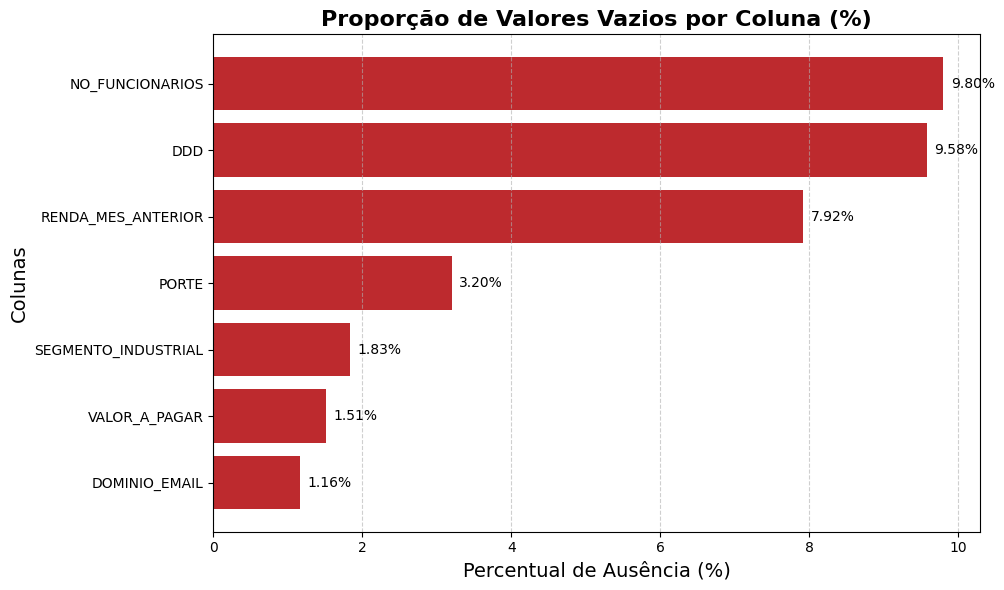

In [6]:
func.plot_missing_values(df)

Agora vamos analisar a quantidade de daddos vazios da Coluna `NO_FUNCIONARIOS`, pelo gráfico temos 9,8% de dados ausentes. Vamos olhar mais de perto as insformações desta feature e planejar uma forma de tratar esse problema. 

A primeira coisa que podemos fazer é usar o método `describe()` que gera um resumo estatístico rápido de um DataFrame ou Série, fornecendo métricas como contagem, média, desvio padrão, mínimo, máximo e quartis para colunas numéricas, e contagem, valores únicos, moda (mais frequente) e frequência para colunas categóricas, ajudando a entender a distribuição e as características dos dados. 

In [7]:
df.describe().style.background_gradient(cmap='Blues')

,ID_CLIENTE,VALOR_A_PAGAR,TAXA,RENDA_MES_ANTERIOR,NO_FUNCIONARIOS
count,77414.000000,76244.000000,77414.000000,71282.000000,69827.000000
mean,4662270147931493376.000000,46590.777166,6.789623,291438.084103,117.692812
std,2665719403408342528.000000,46433.929580,1.798225,213293.159141,18.779624
min,8784237149961904.000000,0.100000,4.990000,105.000000,0.000000
25%,2369364892942408192.000000,18765.362500,5.990000,134074.250000,105.000000
50%,4817816966382229504.000000,34758.695000,5.990000,240502.000000,118.000000
75%,6969348581033924608.000000,60933.837500,6.990000,396250.000000,130.000000
max,9206030810342980608.000000,4400000.000000,11.990000,1682759.000000,198.000000


In [8]:
# Soma o número de empresas que aparecem com 0 funcionários e exclui elas 
df['NO_FUNCIONARIOS'].eq(0).sum()
df = df[df['NO_FUNCIONARIOS'] != 0]

Agora que eliminamos os valores zerados, podemos estudar a relação entre número de funcionários e o porte da empresa, isso pode nos ajudar a entender qual o perfil de cada instituição.

In [9]:
# Relação entre número de funcionarios e o tamanho da empresa levando em consideração a mediana
df.groupby('PORTE')['NO_FUNCIONARIOS'].median().to_frame().style.background_gradient(cmap='Blues')

,NO_FUNCIONARIOS
PORTE,
GRANDE,121.000000
MEDIO,116.000000
PEQUENO,114.000000


In [10]:
# Groupby das colunas  PORTE, SEGMENTO_INDUSTRIAL e NO_FUNCIONARIOS calculando a mediana
df.groupby(['PORTE', 'SEGMENTO_INDUSTRIAL'])['NO_FUNCIONARIOS'].median().to_frame().style.background_gradient(cmap='Blues')

Temos números bem próximos no que diz respeito ao número de funcionários e o segmento industrial em que a empresa atual isso pode influenciar fatores como a escala de produção necessária, o investimento de capital intensivo e a complexidade das operações.

Vamos preencher os dados ausentes com está informação respeitando o porte e o segmento em que a empresa atual.

In [11]:
# Imputação dos Valores da coluna VALOR_A_PAGAR
mediana_funcionario = df.groupby(['PORTE', 'SEGMENTO_INDUSTRIAL'])['NO_FUNCIONARIOS'].transform('median')
df['NO_FUNCIONARIOS'] = df['NO_FUNCIONARIOS'].fillna(mediana_funcionario)

Ao reavaliarmos a quantidade de dados ausentes na coluna `NO_FUNCIONARIOS`, observamos que ainda existem valores faltantes no dataset. Isso ocorre porque, ao utilizarmos as variáveis `PORTE` e `SEGMENTO_INDUSTRIAL` para realizar operações de groupby, as linhas que continham valores ausentes nessas colunas não foram consideradas nos agrupamentos, impossibilitando o tratamento completo de todas as observações do conjunto de dados.

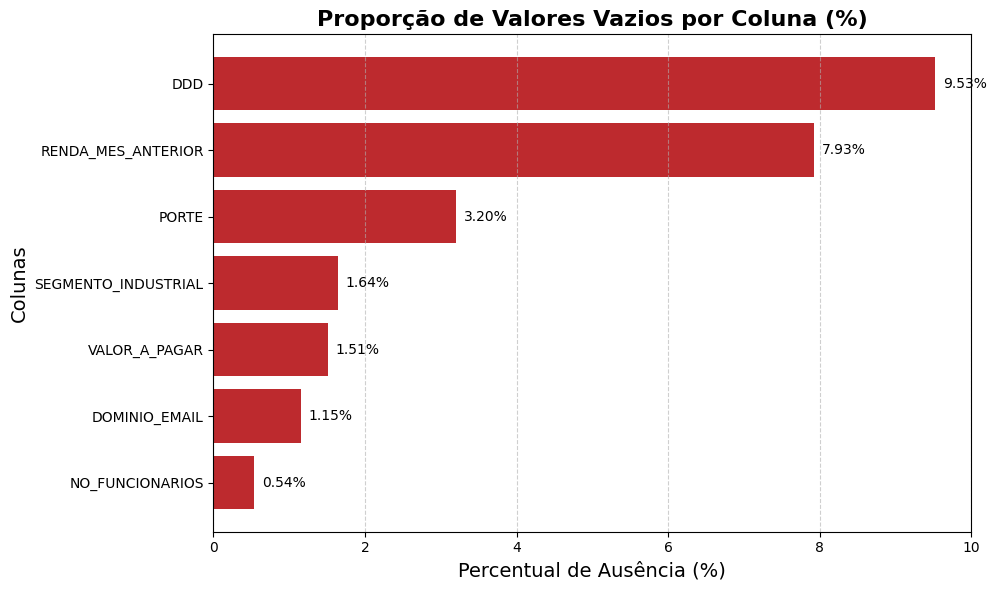

In [12]:
func.plot_missing_values(df)

Os valores que continuam vazios, irei completar com a média.

In [13]:
# Calcula a mediana
media = df['NO_FUNCIONARIOS'].mean()

# Preenche os valores ausentes com a mediana
df['NO_FUNCIONARIOS'] = df['NO_FUNCIONARIOS'].fillna(media)

A coluna `DDD` não será utilizada na análise exploratória nem na construção do modelo de machine learning. Além disso, aproximadamente 10% dos seus registros apresentam valores ausentes. Considerando sua baixa relevância para o problema em estudo e a quantidade significativa de dados faltantes, optou-se pela exclusão dessa variável do dataset.

In [14]:
# Exclusão da coluna DDD
df = df.drop(['DDD'], axis=1)

Para as variáveis categóricas `PORTE`, `SEGMENTO_INDUSTRIAL` e `DOMINIO_EMAIL`, adotou-se a imputação pela moda como estratégia para o tratamento de valores ausentes, por se tratar do valor mais representativo dessas distribuições.

In [15]:
# Calcula a moda (valor mais frequente)
moda_valor = df['PORTE'].mode()[0]
moda_seg = df['SEGMENTO_INDUSTRIAL'].mode()[0]
moda_email = df['DOMINIO_EMAIL'].mode()[0]

# Preenche os valores vazios com a moda
df['PORTE'] = df['PORTE'].fillna(moda_valor)
df['SEGMENTO_INDUSTRIAL'] = df['SEGMENTO_INDUSTRIAL'].fillna(moda_seg)
df['DOMINIO_EMAIL'] = df['DOMINIO_EMAIL'].fillna(moda_email)

A coluna `VALOR_A_PAGAR` não será imputada de forma isolada. Para aumentar a precisão, os valores ausentes serão estimados a partir de uma análise conjunta com as colunas `PORTE` e `NO_FUNCIONARIOS`, que influenciam diretamente esse valor.

A mesma abordagem será adotada na coluna `RENDA_MES_ANTERIOR`, mas desta vez usarei outras variáveis `PORTE`, `SEGMENTO_INDUSTRIAL` e `TAXA`.

In [16]:
# Imputação dos Valores da coluna VALOR_A_PAGAR
mediana_valor_pagar = df.groupby(['PORTE', 'NO_FUNCIONARIOS'])['VALOR_A_PAGAR'].transform('median')
df['VALOR_A_PAGAR'] = df['VALOR_A_PAGAR'].fillna(mediana_valor_pagar)

# Imputação dos Valores da coluna RENDA_MES_ANTERIOR
mediana_renda = df.groupby(['PORTE', 'SEGMENTO_INDUSTRIAL', 'TAXA'])['RENDA_MES_ANTERIOR'].transform('median')
df["RENDA_MES_ANTERIOR"] = df["RENDA_MES_ANTERIOR"].fillna(mediana_renda)

Após o tratamento e a imputação dos valores ausentes, o conjunto de dados encontra-se completo e consistente, estando pronto para a realização da análise exploratória dos dados (Exploratory Data Analysis – EDA).

In [17]:
# Dataset limpo e sem valores nulos nem vazios.
df.to_parquet('../data-processed/dataset_limpo.parquet', engine='pyarrow')
display(df)

,ID_CLIENTE,SAFRA_REF,DATA_EMISSAO_DOCUMENTO,DATA_PAGAMENTO,DATA_VENCIMENTO,VALOR_A_PAGAR,TAXA,RENDA_MES_ANTERIOR,NO_FUNCIONARIOS,DATA_CADASTRO,FLAG_PF,SEGMENTO_INDUSTRIAL,DOMINIO_EMAIL,PORTE,CEP_2_DIG
0,1661240395903230676,2018-08,2018-08-17,2018-09-06,2018-09-06,35516.41,6.99,217640.0,115.0,2013-08-22,Juridico,Serviços,YAHOO,PEQUENO,65
1,1661240395903230676,2018-08,2018-08-19,2018-09-11,2018-09-10,17758.21,6.99,217640.0,115.0,2013-08-22,Juridico,Serviços,YAHOO,PEQUENO,65
2,1661240395903230676,2018-08,2018-08-26,2018-09-18,2018-09-17,17431.96,6.99,217640.0,115.0,2013-08-22,Juridico,Serviços,YAHOO,PEQUENO,65
3,1661240395903230676,2018-08,2018-08-30,2018-10-11,2018-10-05,1341.00,6.99,217640.0,115.0,2013-08-22,Juridico,Serviços,YAHOO,PEQUENO,65
4,1661240395903230676,2018-08,2018-08-31,2018-09-20,2018-09-20,21309.85,6.99,217640.0,115.0,2013-08-22,Juridico,Serviços,YAHOO,PEQUENO,65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77409,2951563549197799278,2021-06,2021-06-30,2021-07-16,2021-07-16,89980.00,5.99,280343.0,161.0,2000-08-15,Juridico,Comércio,AOL,PEQUENO,13
77410,5220206408301580591,2021-06,2021-06-30,2021-08-16,2021-08-16,42239.00,5.99,235315.0,87.0,2021-04-08,Juridico,Indústria,GMAIL,GRANDE,25
77411,5860276371789140450,2021-06,2021-06-30,2021-07-16,2021-07-16,20921.50,5.99,100006.0,122.0,2011-02-15,Juridico,Serviços,HOTMAIL,GRANDE,67
77412,2814790209436551216,2021-06,2021-06-30,2021-07-16,2021-07-16,90231.05,6.99,234489.0,115.0,2021-05-13,Juridico,Serviços,YAHOO,MEDIO,14


## 2.1 Tratamento dos Dados de Teste

Uma etapa fundamental em projetos de Machine Learning é garantir que os dados de teste passem pelos mesmos procedimentos de tratamento aplicados aos dados de treino. Isso assegura a consistência dos tipos de dados, formatos e distribuições das variáveis no momento da aplicação do modelo.

Caso esse alinhamento não seja respeitado, podem ocorrer problemas como incompatibilidade de features, erros de execução ou degradação do desempenho do modelo, comprometendo a generalização e a confiabilidade das previsões.

É essencial que o número de colunas (características ou features) seja exatamente o mesmo nas bases de dados de treino e teste.

Isso é um requisito fundamental para a maioria dos algoritmos de machine learning por várias razões:
1. **Consistência do Modelo**: O modelo é treinado para aprender um padrão específico com base em um conjunto fixo de entradas (colunas). Para fazer uma previsão, ele espera receber exatamente as mesmas entradas na mesma ordem.
2. **Mapeamento de Características**: Se a base de teste tiver uma coluna a menos ou a mais, o algoritmo não saberá como mapear os dados de entrada para os pesos e vieses que aprendeu durante o treinamento.
3. **Integridade dos Dados**: Ambas as bases devem representar a mesma estrutura de dados do problema que você está tentando resolver.

O que deve ser igual:
- **Número de colunas**: Exatamente o mesmo.
- **Nomes das colunas**: Devem coincidir para garantir que o algoritmo use os dados corretos (ex: a coluna 'idade' na base de treino deve ser a 'idade' na base de teste).
- **Ordem das colunas**: A maioria das bibliotecas de machine learning requer que a ordem seja idêntica.

In [18]:
# Lendo o dataset de teste
df_teste = pd.read_csv('../data-raw/base_pagamentos_teste.csv', sep = ';')

display(df_teste)

,ID_CLIENTE,SAFRA_REF,DATA_EMISSAO_DOCUMENTO,DATA_VENCIMENTO,VALOR_A_PAGAR,TAXA
0,5058298901476893676,2021-07,2021-07-14,2021-08-04,11204.75,4.99
1,274692171162531764,2021-07,2021-07-08,2021-08-23,60718.50,5.99
2,274692171162531764,2021-07,2021-07-11,2021-08-25,60718.50,5.99
3,274692171162531764,2021-07,2021-07-16,2021-08-30,62250.00,5.99
4,465309249432033993,2021-07,2021-07-05,2021-07-30,26593.95,6.99
...,...,...,...,...,...,...
12270,705648002974742140,2021-11,2021-11-25,2021-12-13,47010.00,6.99
12271,4993499380140734678,2021-11,2021-11-25,2021-12-13,122875.35,8.99
12272,4614484019183480654,2021-11,2021-11-26,2028-09-30,302200.00,5.99
12273,1299146298565441811,2021-11,2021-11-26,2021-12-13,143791.85,5.99


In [19]:
func.df_summary_report(df_teste)

,Coluna,Tipo,Quantidade de Dados Não Vazios,Quantidade de Dados Vazios,Valores Únicos,Valor mais Frequente,Frequência,Porcentagem de Unicidade,Porcentagem de Valor Vazios (%),Consumo de Memória - Total: 0.88 (MB)
0,ID_CLIENTE,int64,12275,0,976,1156053485989336481,213,7.95,0.00,0.093651
1,SAFRA_REF,str,12275,0,5,2021-10,2673,0.04,0.00,0.175595
2,DATA_EMISSAO_DOCUMENTO,str,12275,0,150,2021-11-04,177,1.22,0.00,0.210714
3,DATA_VENCIMENTO,str,12275,0,141,2021-09-06,293,1.15,0.00,0.210714
4,VALOR_A_PAGAR,float64,12144,131,10850,999.000000,90,88.39,1.07,0.093651
5,TAXA,float64,12275,0,5,5.990000,3937,0.04,0.00,0.093651


Para que o modelo de Machine Learning possa ser aplicado corretamente, é essencial que a base de teste não contenha valores nulos ou vazios. Dessa forma, será realizada uma análise da coluna `VALOR_A_PAGAR` a fim de definir uma estratégia adequada para o preenchimento dos dados faltantes.

Considerando a presença de possíveis outliers e a natureza assimétrica da variável, optou-se pela imputação dos valores ausentes utilizando a mediana, por ser uma medida mais robusta do que a média.

In [20]:
# Cálculo da mediana  
mediana_teste = df_teste['VALOR_A_PAGAR'].median()
df_teste['VALOR_A_PAGAR'] = df_teste['VALOR_A_PAGAR'].fillna(mediana_teste)

# Transformar colunas object para datetime
cols = ['DATA_EMISSAO_DOCUMENTO', 'DATA_VENCIMENTO']
df_teste[cols] = df_teste[cols].apply(pd.to_datetime)

Variáveis do tipo data, como dia/mês/ano, carregam informações temporais relevantes que não podem ser utilizadas diretamente pelos modelos de Machine Learning. Por esse motivo, é fundamental realizar um tratamento adequado desse tipo de dado, convertendo-o para um formato que permita a extração de conhecimento.

A partir das datas, é possível criar novas features que capturam padrões temporais importantes, como ano, mês, dia, dia da semana ou períodos específicos, permitindo que o modelo identifique sazonalidades, tendências e comportamentos recorrentes ao longo do tempo.

Esse processo de feature engineering contribui significativamente para o aumento do poder preditivo do modelo, pois transforma informações temporais brutas em variáveis numéricas mais interpretáveis e relevantes para a tarefa de aprendizado.

In [21]:
# Coluna Emissão Documentos
df_teste["Mes_Emissao_Documento"] = df_teste["DATA_EMISSAO_DOCUMENTO"].dt.month
df_teste["Dia_Emissao_Documento"] = df_teste["DATA_EMISSAO_DOCUMENTO"].dt.day

# Coluna Mês Vencimento 
df_teste["Mes_Vencimento"] = df_teste["DATA_VENCIMENTO"].dt.month
df_teste["Dia_Vencimento"] = df_teste["DATA_VENCIMENTO"].dt.day

display(df_teste)

,ID_CLIENTE,SAFRA_REF,DATA_EMISSAO_DOCUMENTO,DATA_VENCIMENTO,VALOR_A_PAGAR,TAXA,Mes_Emissao_Documento,Dia_Emissao_Documento,Mes_Vencimento,Dia_Vencimento
0,5058298901476893676,2021-07,2021-07-14,2021-08-04,11204.75,4.99,7,14,8,4
1,274692171162531764,2021-07,2021-07-08,2021-08-23,60718.50,5.99,7,8,8,23
2,274692171162531764,2021-07,2021-07-11,2021-08-25,60718.50,5.99,7,11,8,25
3,274692171162531764,2021-07,2021-07-16,2021-08-30,62250.00,5.99,7,16,8,30
4,465309249432033993,2021-07,2021-07-05,2021-07-30,26593.95,6.99,7,5,7,30
...,...,...,...,...,...,...,...,...,...,...
12270,705648002974742140,2021-11,2021-11-25,2021-12-13,47010.00,6.99,11,25,12,13
12271,4993499380140734678,2021-11,2021-11-25,2021-12-13,122875.35,8.99,11,25,12,13
12272,4614484019183480654,2021-11,2021-11-26,2028-09-30,302200.00,5.99,11,26,9,30
12273,1299146298565441811,2021-11,2021-11-26,2021-12-13,143791.85,5.99,11,26,12,13


In [22]:
df_teste.to_parquet('../data-processed/dataset_teste_limpo.parquet', engine='pyarrow')
display(df_teste)

,ID_CLIENTE,SAFRA_REF,DATA_EMISSAO_DOCUMENTO,DATA_VENCIMENTO,VALOR_A_PAGAR,TAXA,Mes_Emissao_Documento,Dia_Emissao_Documento,Mes_Vencimento,Dia_Vencimento
0,5058298901476893676,2021-07,2021-07-14,2021-08-04,11204.75,4.99,7,14,8,4
1,274692171162531764,2021-07,2021-07-08,2021-08-23,60718.50,5.99,7,8,8,23
2,274692171162531764,2021-07,2021-07-11,2021-08-25,60718.50,5.99,7,11,8,25
3,274692171162531764,2021-07,2021-07-16,2021-08-30,62250.00,5.99,7,16,8,30
4,465309249432033993,2021-07,2021-07-05,2021-07-30,26593.95,6.99,7,5,7,30
...,...,...,...,...,...,...,...,...,...,...
12270,705648002974742140,2021-11,2021-11-25,2021-12-13,47010.00,6.99,11,25,12,13
12271,4993499380140734678,2021-11,2021-11-25,2021-12-13,122875.35,8.99,11,25,12,13
12272,4614484019183480654,2021-11,2021-11-26,2028-09-30,302200.00,5.99,11,26,9,30
12273,1299146298565441811,2021-11,2021-11-26,2021-12-13,143791.85,5.99,11,26,12,13


<div style="
    background-color: #3D5A73;
    color: white;
    width: 700px;
    height: 120px;                 /* define altura fixa */
    margin: 20px auto;
    border-radius: 15px;
    display: flex;                 /* ativa flexbox */
    align-items: center;           /* centraliza vertical */
    justify-content: center;       /* centraliza horizontal */
">
    <h1 style="margin: 0;">3. Análise Exploratória dos Dados</h1>
</div>

A análise exploratória dos dados (Exploratory Data Analysis – EDA) é uma etapa fundamental em projetos de Data Science e Machine Learning, pois permite compreender a estrutura do dataset, identificar padrões, relações e anomalias, além de avaliar a qualidade dos dados. Por meio de estatísticas descritivas e visualizações, a EDA auxilia na detecção de outliers, vieses e possíveis problemas que podem impactar o desempenho dos modelos. Além disso, essa etapa fornece insights valiosos que orientam decisões sobre engenharia de features, seleção de variáveis e escolha de algoritmos, contribuindo para a construção de modelos mais robustos e confiáveis.

In [23]:
df_flag = (df.FLAG_PF.value_counts(normalize=True)*100).to_frame().style.format("{:.2f}%").background_gradient(cmap='Blues')
df_flag

,proportion
FLAG_PF,
Juridico,99.91%
Pessoa_Fisica,0.09%


Quase 100% dos dados é composto por empresa do tipo PJ (Pessoa Jurídica). Isso nos revela um potência problema que pode afetar todo o dataset, o **Desbalanceamento de Dados**. 

Dados Desbalanceados podem ser definidos quando temos um pequena incidência de uma categoria dentro de um dataset (classe minoritária) em comparação com as demais categorias (classe majoritária). Na maioria dos casos, isso faz com que tenhamos muitas informações a respeito das categorias mais indidentes e menos das minoritárias. 

Quando formos construir o modelo de machine learning devemos tratar esse problema, pois se não lidados com isso de alguma maneira, dados desbalanceados podem acarretar em problemas na construção de modelos e geração de previsões.

> Mas porque não tratar agora? Bom, nem sempre dados desbalanceados podem ser um problema, antes de montarmos qualquer modelo, explorar os dados e buscar insights lógicos a respeito dos dados que temos é sempre importante. Em muitos casos, o fato de estarmos trabalhando com dados desbalanceados durante a análise nem sempre trás prejuízos aos seus insights uma vez que algumas conclusões não necessitam de uma quantidade elevada (porém suficiente) de dados. Ademais, é de se perceber que, em muitos casos, descobrir o “porquê” do desbalanceamento pode trazer informações válidas para a resolução do problema.

## 3.2 Análise das Variáveis Categóricas
Dando continuidade na exploração dos dados, vamos analisar as variáveis categóricas presentes no dataset.

Essa etapa é importante para a análise exploratória, pois permite identificar características da população estudada e possíveis desequilíbrios que devem ser considerados nas etapas posteriores de preparação dos dados e modelagem.

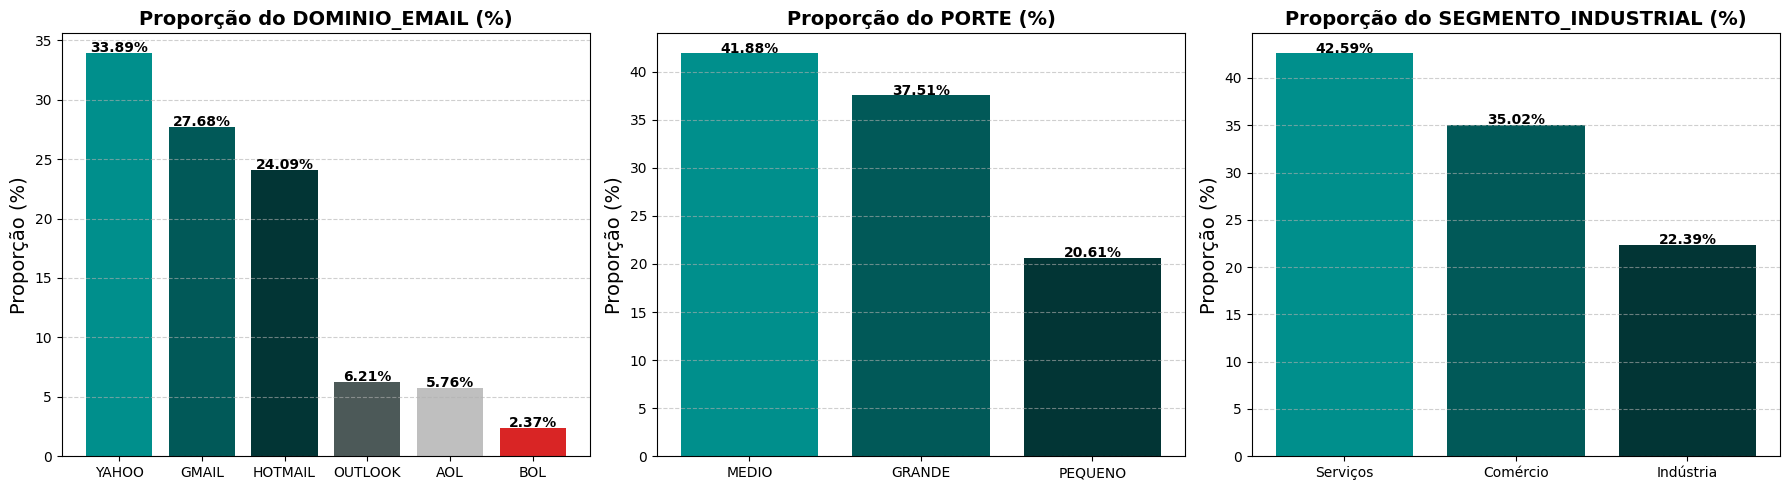

In [24]:
func.plot_proportion_bar(df, ["DOMINIO_EMAIL","PORTE", "SEGMENTO_INDUSTRIAL"], palette=customPalette)

A análise das proporções permite compreender a composição da base de dados e identificar possíveis concentrações ou desequilíbrios nas variáveis categóricas. Observa-se que a variável `DOMÍNIO_EMAIL` apresenta maior concentração em três categorias: Yahoo, Gmail e Hotmail. Enquanto `PORTE` possui uma distribuição relativamente equilibrada entre empresas médias, grandes e pequenas. 

Já `SEGMENTO_INDUSTRIAL` apresenta predominância dos setores de Serviços e Comércio em relação à Indústria.

## 3.3 Relação entre Número de Funcionários e o Porte da Empresa
Vamos analisar agora o comportamento das variáveis correspondentes ao `NO_FUNCIONARIOS` e o `PORTE`.

In [25]:
# Relação entre número de funcionarios e o tamanho da empresa
df.groupby('PORTE')['NO_FUNCIONARIOS'].describe().style.background_gradient(cmap='Blues')

,count,mean,std,min,25%,50%,75%,max
PORTE,,,,,,,,
GRANDE,28984.000000,120.494141,15.795825,70.000000,111.000000,121.000000,130.000000,198.000000
MEDIO,32358.000000,117.820208,17.181092,60.000000,107.000000,117.000000,129.000000,179.000000
PEQUENO,15925.000000,113.525570,18.401174,67.000000,100.000000,114.000000,124.000000,187.000000


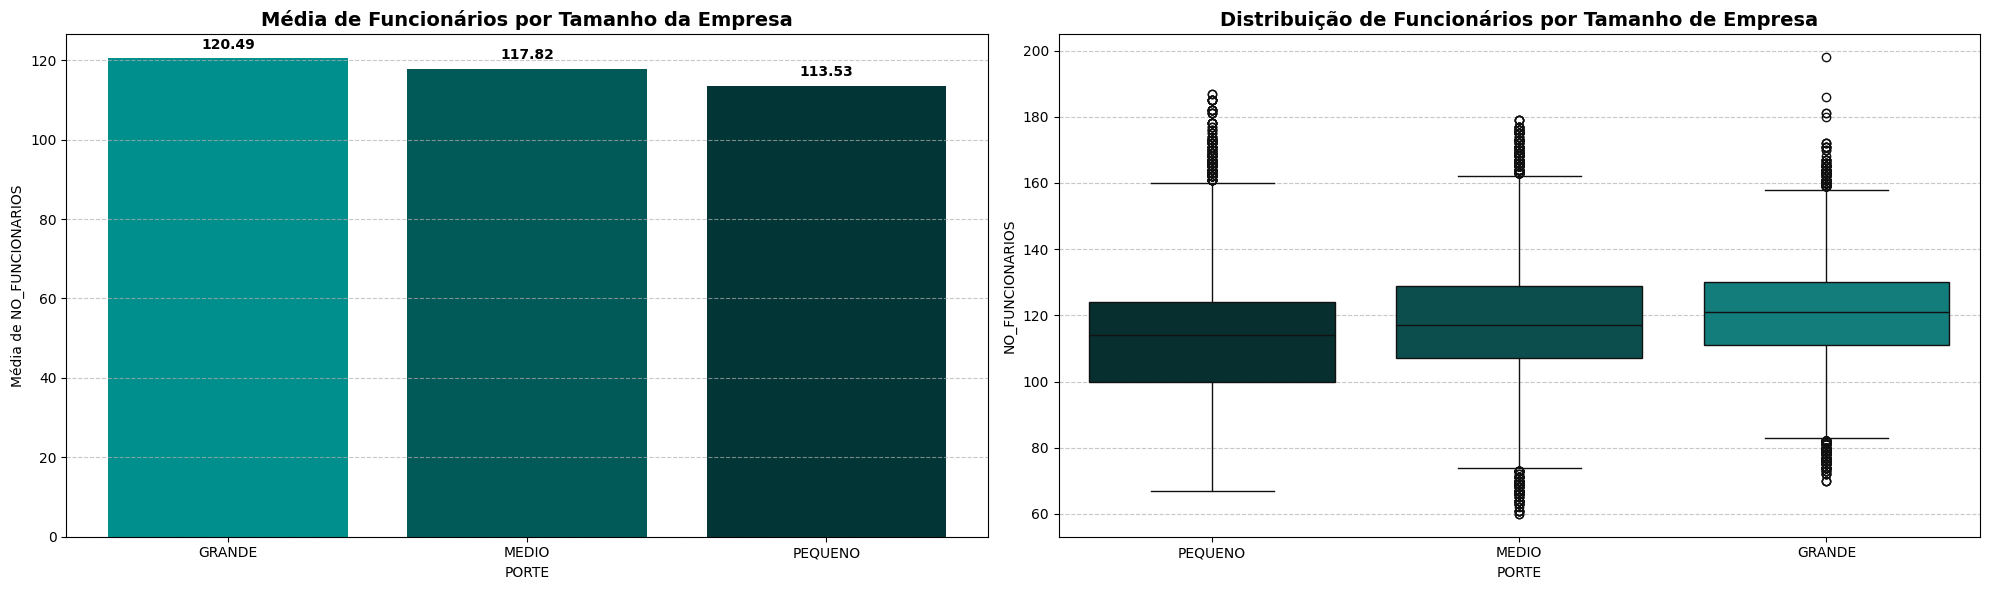

In [26]:
func.plot_mean_and_distribution(df, coluna1="PORTE", coluna2="NO_FUNCIONARIOS")

A primeira conclusão é que existe uma pequena diferença entre os portes, mas ela é relativamente pequena.
- **Empresas grandes**: 120 funcionários
- **Empresas médias**: 118 funcionários
- **Empresas pequenas**: 114 funcionários

Isso é um resultado interessante, porque esperaríamos que empresas grandes tivessem uma quantidade de funcionários muito maior que empresas pequenas. Nesse conjunto de dados, porém, as médias estão bastante próximas.

O boxplot complementa essa análise ao evidenciar que as distribuições apresentam medianas próximas, porém com uma quantidade significativa de valores discrepantes, principalmente para empresas com mais de 160 funcionários. Dessa forma, a média isoladamente não representa completamente o comportamento da variável, sendo importante considerar também sua dispersão e os outliers.

Esse resultado também sugere a necessidade de investigar como a variável `PORTE` foi definida na base, uma vez que seria esperado encontrar diferenças mais expressivas no número de funcionários entre empresas pequenas, médias e grandes.


## 3.4 Correlação entre Porte da Empresa e Segmento em ela Atua
Existe uma correlação indireta e contextual entre o porte da empresa e o segmento em que ela atua. Podemos examinar como segmento influencia os critérios de classificação e tende a favorecer determinados portes devido a características operacionais e de mercado. 

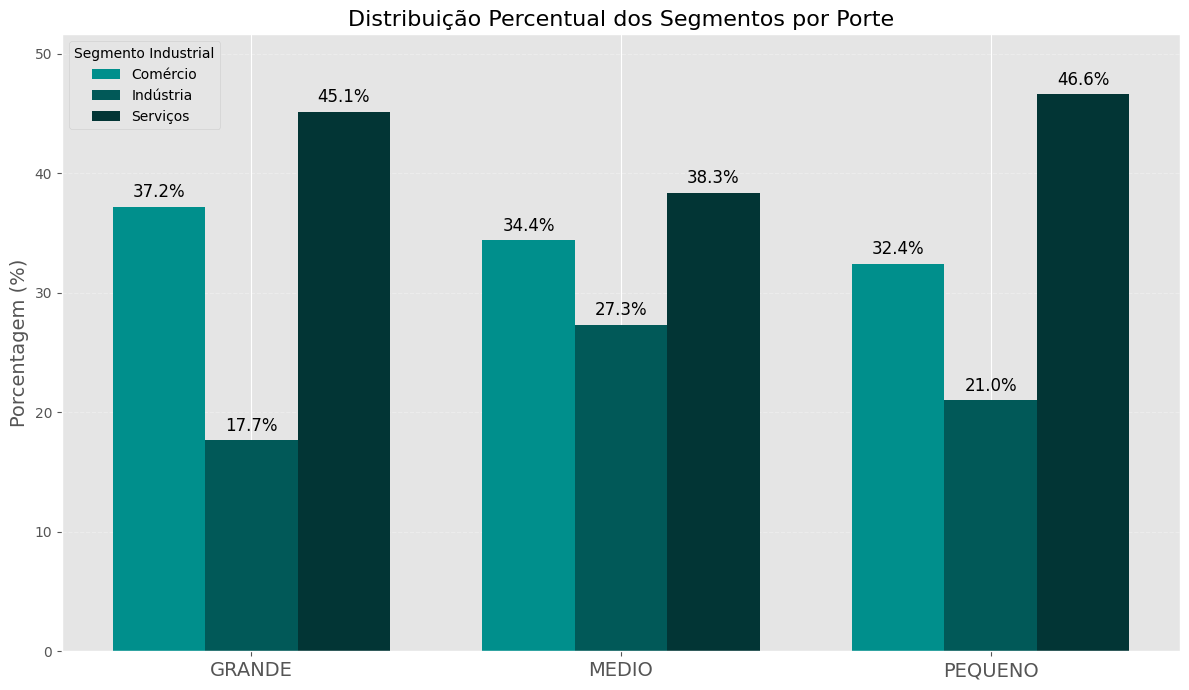

In [27]:
func.plot_segmento_por_porte(df)

## 3.5 Localização das Empresas
De acordo com site dos correios, podemos obter informações sobre como o CEP funciona e o que os digitos pode nos dizer. Cada número de CEP corrensponde a uma Região, Sub-região, Setor, Subsetor, Divisor de Subsetor e Identificadores de Distribuição.

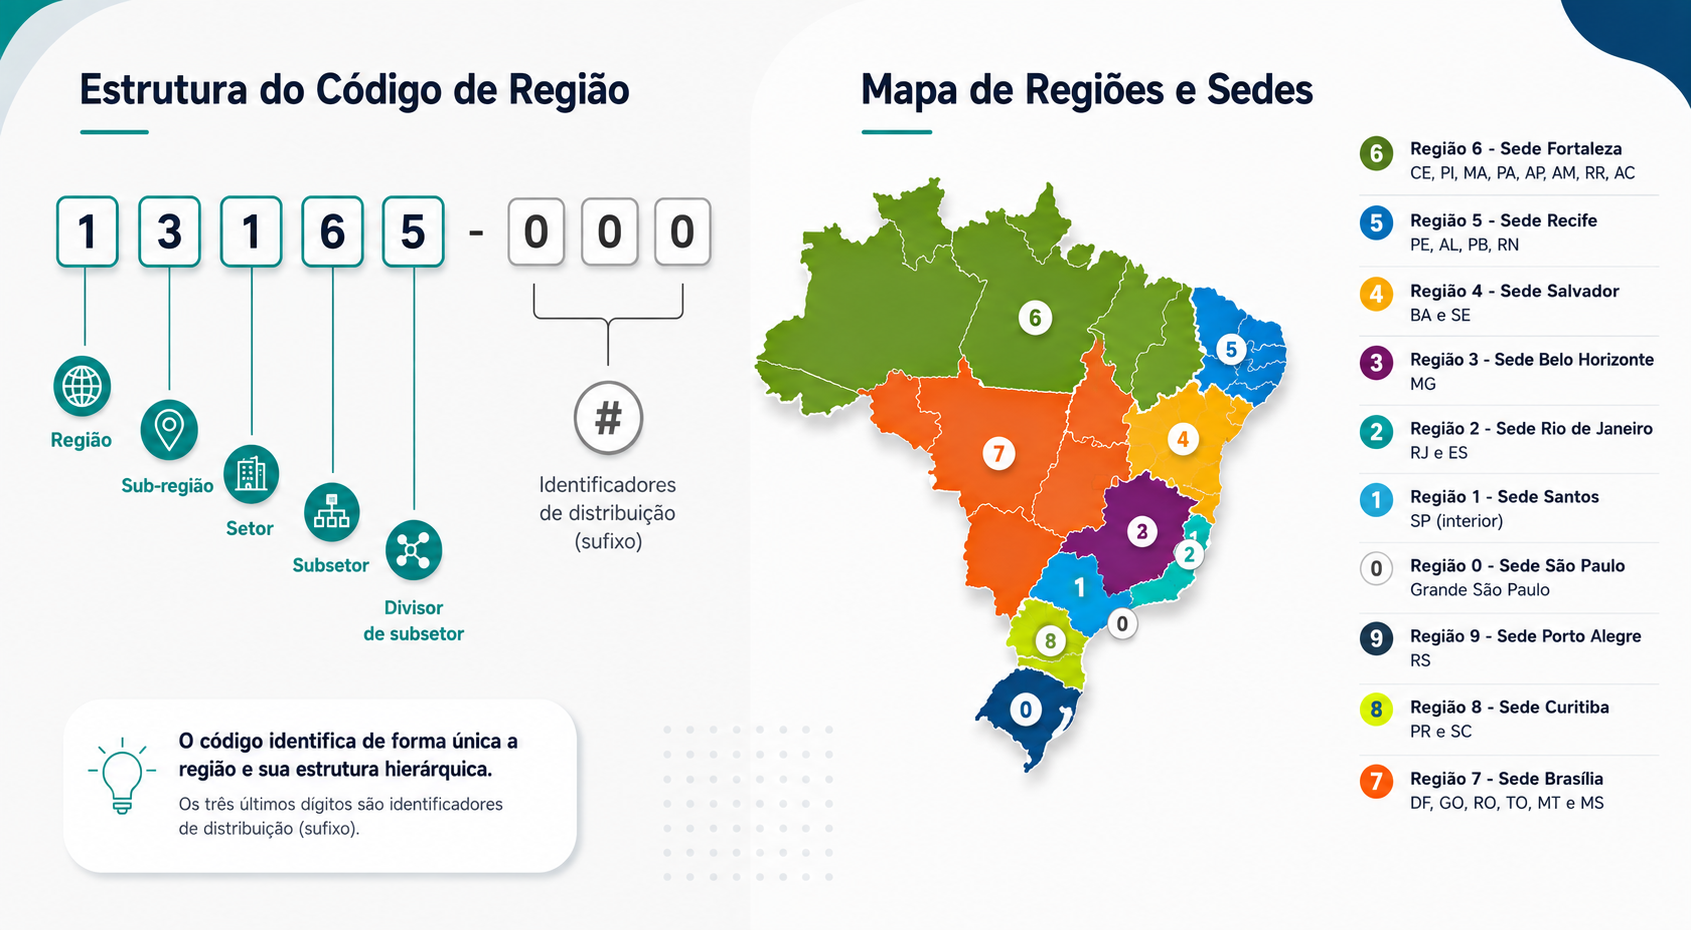

Analisando os primeiros dois dígitos do CEP, podemos analisar a localização das empresas.

In [28]:
df['CEP_2_DIG'].value_counts().head(10).to_frame().style.background_gradient(cmap='Blues')

,count
CEP_2_DIG,
13,3884
35,2845
68,2603
89,2588
86,2135
37,2107
12,2076
78,2006
75,1773


O Brasil foi divido em dez regiões postais, indo do **0 ao 9**, o que define o primeiro número do CEP. A distribuição foi feita no sentido anti-horário, a partir do estado de São Paulo.
- **Região 0 :** grande São Paulo;
- **Região 1:** interior de São Paulo;
- **Região 2:** Rio de Janeiro e Espírito Santo;
- **Região 3:** Minas Gerais;
- **Região 4:** Bahia e Sergipe;
- **Região 5:** Pernambuco, Alagoas, Paraíba e Rio Grande do Norte;
- **Região 6:** Ceará, Piauí, Maranhão, Pará, Roraima, Amapá, Acre e Amazonas;
- **Região 7:** Distrito Federal, Goiás, Rondônia, Tocantins, Mato Grosso e Mato Grosso do Sul;
- **Região 8:** Paraná e Santa Catarina;
- **Região 9:** Rio Grande do Sul.

Com base nessa informação podemos ver que o top 10 localidades das empresas são:
- **1** - Interior de São Paulo;
- **2** - Minas Gerais;
- **3** - Ceará, Piauí, Maranhão, Pará, Roraima, Amapá, Acre e Amazonas;
- **4 e 5** - Paraná e Santa Catarina;
- **6** - Minas Gerais;
- **7** - Interior de São Paulo
- **8 e 9** - Distrito Federal, Goiás, Rondônia, Tocantins, Mato Grosso e Mato Grosso do Sul;
- **10** - Minas Gerais.

<div style="
    background-color: #3D5A73;
    color: white;
    width: 800px;
    height: 120px;                 /* define altura fixa */
    margin: 20px auto;
    border-radius: 15px;
    display: flex;                 /* ativa flexbox */
    align-items: center;           /* centraliza vertical */
    justify-content: center;       /* centraliza horizontal */
">
    <h1 style="margin: 0;">4. Visualização da Variável Target (Churn)</h1>
</div>

A análise da variável churned é importante em um projeto de previsão de inadimplência porque ela pode representar o cancelamento ou abandono do relacionamento do cliente com a empresa. Clientes que encerram seu relacionamento podem apresentar comportamentos financeiros diferentes daqueles que permanecem ativos, o que pode fornecer informações relevantes para a identificação de perfis associados ao risco de inadimplência.

Além disso, analisar a distribuição de churned permite verificar se existe desbalanceamento entre clientes que permaneceram e clientes que saíram, bem como investigar sua relação com a variável-alvo de inadimplência. Essa análise pode ajudar a identificar possíveis padrões de comportamento e avaliar se o churn deve ser utilizado como variável preditora no modelo, desde que sua informação esteja disponível antes do momento em que a inadimplência é prevista, evitando vazamento de informação (data leakage).

O objetivo deste projeto é desenvolver um modelo de Machine Learning capaz de prever a probabilidade de inadimplência de clientes de uma instituição financeira.

Neste contexto, considera-se cliente inadimplente aquele que realiza o **pagamento com 5 dias ou mais de atraso em relação à data de vencimento**.

Para viabilizar essa previsão, será necessário criar a variável alvo, calculada a partir da diferença, em dias, entre a data de pagamento e a data de vencimento, permitindo classificar cada cliente conforme o critério de inadimplência definido.

In [29]:
# Transformar colunas object para datetime
cols = ['DATA_EMISSAO_DOCUMENTO', 'DATA_PAGAMENTO', 'DATA_VENCIMENTO']
df[cols] = df[cols].apply(pd.to_datetime)

# Cálculo da Inadimplência
df['Churned'] = np.where(((df['DATA_PAGAMENTO'] - df['DATA_VENCIMENTO']).dt.days) >= 5, 1, 0)

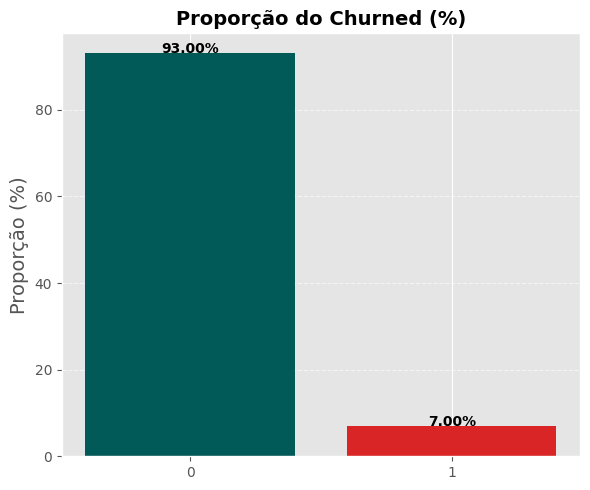

In [33]:
func.plot_proportion_bar(df, columns=["Churned"], palette=["#015958", "#D92525"])

Aqui temos um caso clássico de desbalanceamos de dados, em problemas de **classificação**, dizemos que um **conjunto de dados é desbalanceado quando uma ou mais classes possuem uma quantidade significativamente menor de observações em relação às demais**. Um exemplo comum ocorre em modelos de churn, fraude ou detecção de falhas, nos quais a classe de interesse (como clientes que cancelam o serviço) representa uma pequena parcela do total de registros.

Em resumo, dados desbalanceados exigem cuidados específicos ao longo de todo o processo de modelagem. Ignorar esse aspecto pode levar a conclusões equivocadas e modelos pouco eficazes na prática. Ao combinar técnicas de reamostragem, escolha adequada de métricas e ajustes no processo de decisão do modelo, é possível construir soluções mais robustas, interpretáveis e alinhadas aos objetivos do problema real.

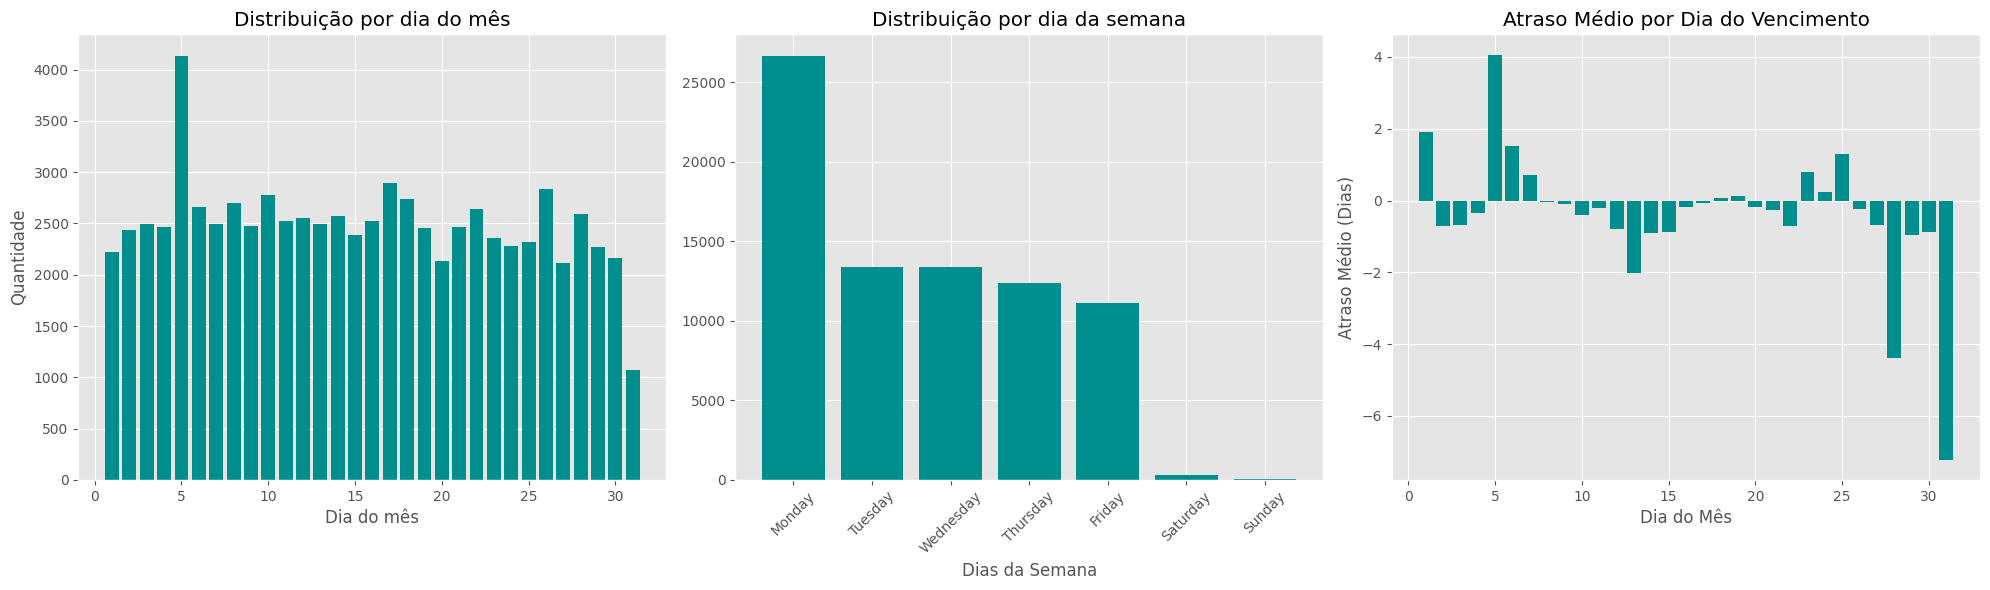

In [31]:
func.plot_pagamento(df)

Neste gráfico vemos a distrubuição das datas dos dias de vencimento do nosso dataset, é possível observar que no dia 5 do mês é onde ocorre a maior quantidade de pagamento. A segunda feira é o dia com maior frequência de pagamento e por fim temos a média da diferença entre o dia de pagamento e vencimento, onde valores positivos indicam atraso, valores zero indicam pagamento em dia e valores negativos indicam pagamento antecipado.

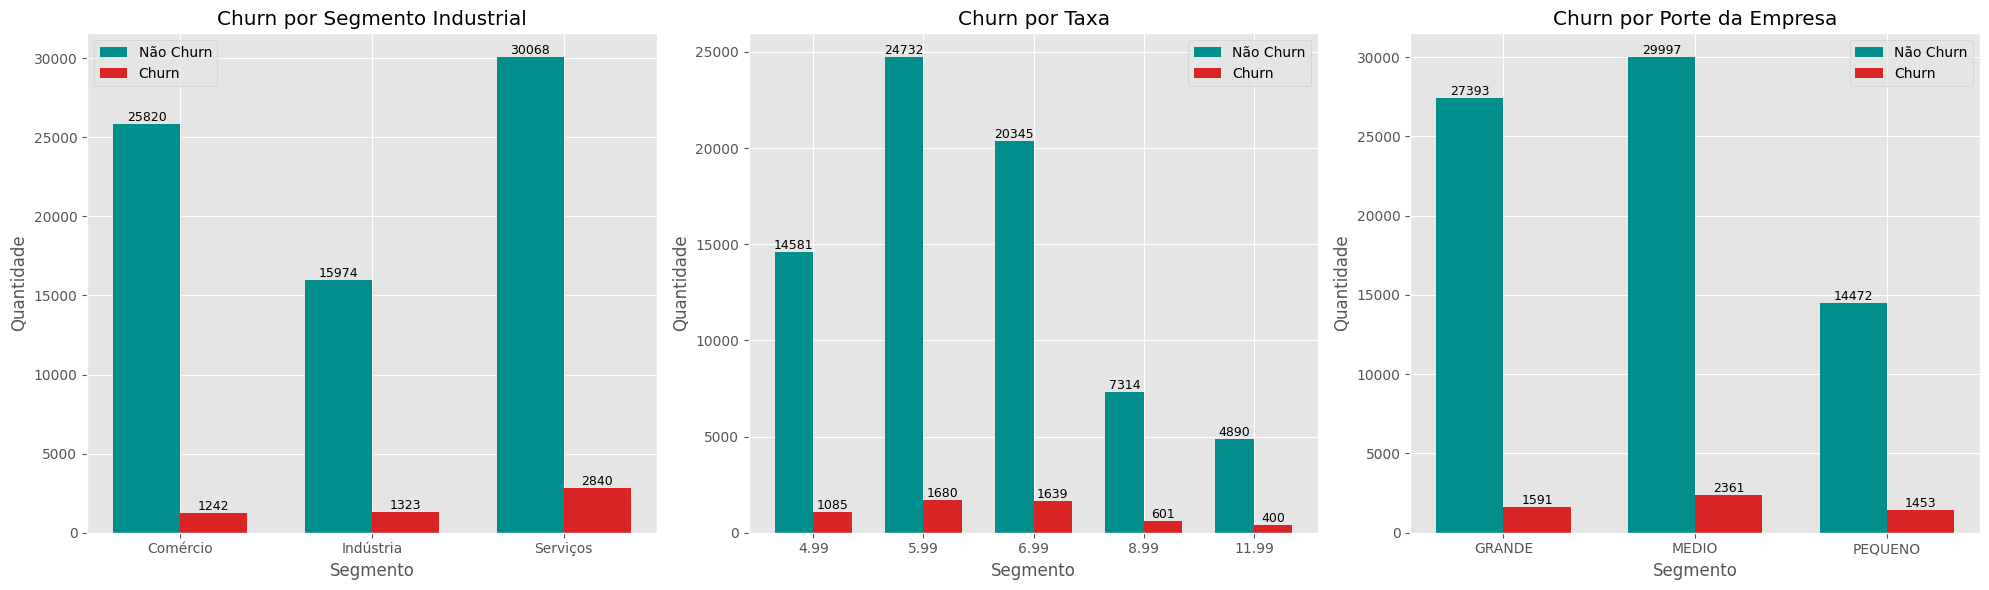

In [32]:
func.plot_churned(df)

Neste outro conjunto de gráficos, quando analisamos a quantidade de churned por segmento industrial vemos que o setor de Serviço é o que apresenta maior número de inadimplência em comparação ao Comércio e Indústrial, essa característica pode ser consequência desse setor representar uma grande parcela dos dados do nosso dataset. Já quando observamos a taxa temos que empresas com taxa de 5.99 são maioria e tem maior churned em relação as demais taxas e o Porte da empresa que Médio se destaca por seus números expressivos. 

<div style="
    background-color: #3D5A73;
    color: white;
    width: 800px;
    height: 120px;                 /* define altura fixa */
    margin: 20px auto;
    border-radius: 15px;
    display: flex;                 /* ativa flexbox */
    align-items: center;           /* centraliza vertical */
    justify-content: center;       /* centraliza horizontal */
">
    <h1 style="margin: 0;">Conclusão</h1>
</div>

Nesta primeira etapa do estudo de caso, o foco foi compreender e preparar o dataset para as fases posteriores de modelagem. Foram aplicadas estratégias de tratamento de dados ausentes, utilizando imputação por média, mediana e abordagens baseadas em relações entre variáveis (groupby), com o objetivo de preservar a consistência e a qualidade das informações.

Além disso, foi realizada uma análise exploratória dos dados, incluindo a descrição das features, visualizações gráficas e investigação das relações entre variáveis. Essa etapa permitiu uma melhor compreensão da estrutura do dataset e do comportamento dos dados.

Por fim, a variável target, a inadimplência, foi analisada em profundidade, buscando identificar padrões, tendências e possíveis correlações com outras variáveis. Os insights obtidos fornecem uma base sólida para a próxima fase do projeto, que consiste na construção de modelos preditivos capazes de estimar o risco de inadimplência.